In [2]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16 
from tensorflow.keras import layers, models


In [3]:

training_set = tf.keras.utils.image_dataset_from_directory(
     r'D:\skindiseasedataset',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),  # Pretrained models usually require 224x224 input size
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="training"
)

validation_set = tf.keras.utils.image_dataset_from_directory(
     r'D:\skindiseasedataset',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="validation"
)


Found 7200 files belonging to 8 classes.
Using 5760 files for training.
Found 7200 files belonging to 8 classes.
Using 1440 files for validation.


Define the Pretrained Model

In [4]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  
# Freeze the base model layers to prevent training

# Add custom layers on top of the pretrained model
cnn = models.Sequential([
    base_model,  # Add the pretrained model as the base
    layers.Flatten(),  # Flatten the output of the base model
    layers.Dense(256, activation='relu'),  # Custom dense layer
    layers.Dropout(0.5),  # Corrected Dropout layer
    layers.Dense(8, activation='softmax')  # Output layer for 8 classes
])


Compile the model

In [5]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Display the model architecture
cnn.summary()

Train the model

In [6]:
training_history = cnn.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=10  # You can increase epochs if needed
)

Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1169s 6s/step - accuracy: 0.2447 - loss: 6.9553 - val_accuracy: 0.3854 - val_loss: 1.6774
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1456s 8s/step - accuracy: 0.4370 - loss: 1.5784 - val_accuracy: 0.4819 - val_loss: 1.4340
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1168s 6s/step - accuracy: 0.5478 - loss: 1.2096 - val_accuracy: 0.5250 - val_loss: 1.3038
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1218s 7s/step - accuracy: 0.6087 - loss: 1.0388 - val_accuracy: 0.5528 - val_loss: 1.2206
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1092s 6s/step - accuracy: 0.6713 - loss: 0.8618 - val_accuracy: 0.5958 - val_loss: 1.1765
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1330s 7s/step - accuracy: 0.7335 - loss: 0.7335 - val_accuracy: 0.6187 - val_loss: 1.1084
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1137s 6s/step - accuracy: 0.7597 - loss: 0.6328 - val_accuracy: 0.6264 - val_loss: 1.0476
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1126s 6s/step - accuracy: 0.7856 - loss: 0.5861 - 

Evaluate the model on the training set

In [7]:

train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)]

# Evaluate the model on the validation set
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

180/180 ━━━━━━━━━━━━━━━━━━━━ 891s 5s/step - accuracy: 0.9548 - loss: 0.1604
Training accuracy: 0.9581597447395325
45/45 ━━━━━━━━━━━━━━━━━━━━ 227s 5s/step - accuracy: 0.6577 - loss: 1.0440
Validation accuracy: 0.6569444537162781


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8

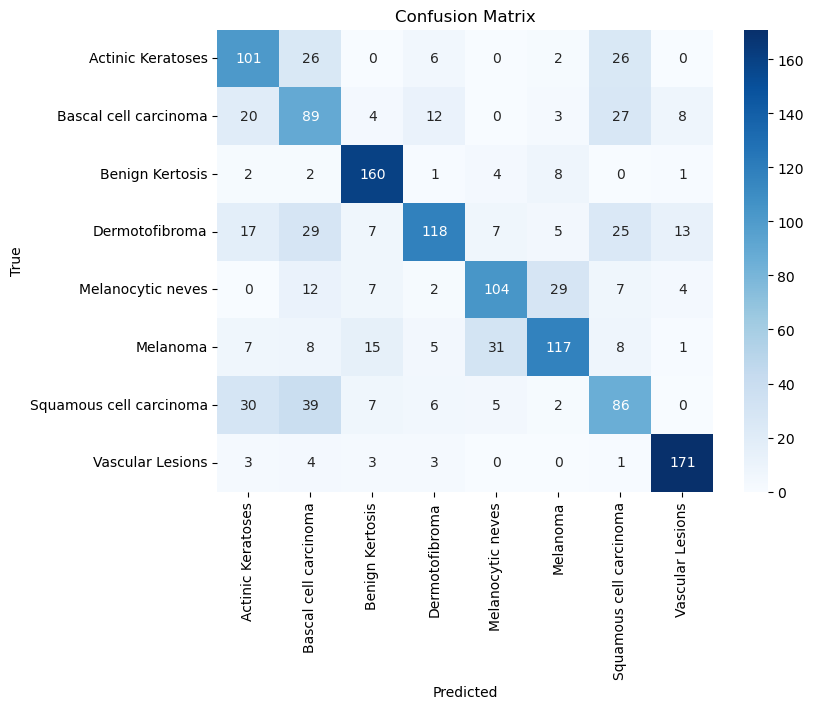

Classification Report:
                          precision    recall  f1-score   support

      Actinic Keratoses       0.56      0.63      0.59       161
  Bascal cell carcinoma       0.43      0.55      0.48       163
        Benign Kertosis       0.79      0.90      0.84       178
         Dermotofibroma       0.77      0.53      0.63       221
      Melanocytic neves       0.69      0.63      0.66       165
               Melanoma       0.70      0.61      0.65       192
Squamous cell carcinoma       0.48      0.49      0.48       175
       Vascular Lesions       0.86      0.92      0.89       185

               accuracy                           0.66      1440
              macro avg       0.66      0.66      0.65      1440
           weighted avg       0.67      0.66      0.66      1440



In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Generate true labels and predictions for the validation set
true_labels = []
predictions = []

for images, labels in validation_set:
    preds = cnn.predict(images)  # Get model predictions
    true_labels.append(np.argmax(labels.numpy(), axis=1))  # True labels
    predictions.append(np.argmax(preds, axis=1))  # Predicted labels

# Flatten the lists into single arrays
true_labels = np.concatenate(true_labels)
predictions = np.concatenate(predictions)

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predictions)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=training_set.class_names, yticklabels=training_set.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(true_labels, predictions, target_names=training_set.class_names))


Plot training and validation accuracy and loss

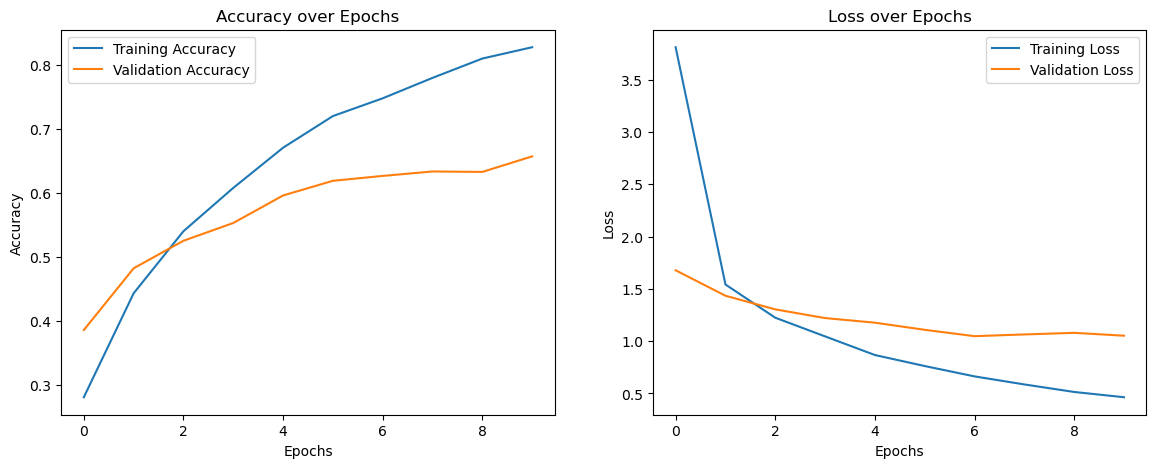

In [9]:

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(training_history.history['accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()
